In [68]:
import pandas as pd
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
# Load counts
counts = pd.read_csv("/hpcwork/p0020567/dana_data/000_Bioinfo_Project/6_PyDESeq2/count_matrix.tsv", sep="\t", index_col=0,header=None,
                     names=['gene_id', 'Quizartinib1', 'Quizartinib2', 'Quizartinib3', 'Untreated1', 'Untreated2']
                     )

# Load metadata
metadata = pd.read_csv("/hpcwork/p0020567/dana_data/000_Bioinfo_Project/6_PyDESeq2/metadata.csv", sep=",", index_col=0,header=None,
                       names=['sample', 'condition']
                       )

In [27]:
metadata

,condition
sample,
Quizartinib1,treated
Quizartinib2,treated
Quizartinib3,treated
Untreated1,untreated
Untreated2,untreated


In [28]:
counts

,Quizartinib1,Quizartinib2,Quizartinib3,Untreated1,Untreated2
gene_id,,,,,
ENSG00000290825.2,0,0,0,0,0
ENSG00000223972.6,0,0,0,0,0
ENSG00000310526.1,81,71,47,5,6
ENSG00000227232.6,0,0,0,0,0
ENSG00000278267.1,0,0,0,0,0
...,...,...,...,...,...
ENSG00000198695.2,10342,13504,12745,17932,15129
ENSG00000210194.1,67,110,66,10,4
ENSG00000198727.2,81746,86021,119329,90581,87959


In [31]:
# Transpose counts so rows = samples
counts = counts.T

# Ensure metadata order matches counts
metadata = metadata.loc[counts.index]

In [ ]:
# 4. Filter low-count genes
counts = counts.loc[:, counts.sum(axis=0) > 10]

In [ ]:
# 5. Create DESeq2 dataset
dds = DeseqDataSet(
    counts=counts,
    metadata=metadata,
    design_factors="condition",
)

/tmp/xu262605/login23-2_190367/ipykernel_216255/1259314605.py:1: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(


In [34]:
# 6. Run DESeq2

dds.deseq2()

Fitting size factors...
... done in 0.01 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 4.25 seconds.

Fitting dispersion trend curve...
... done in 0.36 seconds.

/home/xu262605/.conda/envs/ahi_workshop/lib/python3.12/site-packages/pydeseq2/dds.py:548: UserWarning: As the residual degrees of freedom is less than 3, the distribution of log dispersions is especially asymmetric and likely to be poorly estimated by the MAD.
  self.fit_dispersion_prior()
Fitting MAP dispersions...
... done in 4.12 seconds.

Fitting LFCs...
... done in 2.85 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.



In [53]:
dds

AnnData object with n_obs × n_vars = 5 × 30571
    obs: 'condition', 'size_factors', 'replaceable'
    var: '_normed_means', 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', '_LFC_converged', 'replaced', 'refitted', '_pvalue_cooks_outlier'
    uns: 'trend_coeffs', 'disp_function_type', '_squared_logres', 'prior_disp_var'
    obsm: 'design_matrix', '_mu_LFC', '_hat_diagonals'
    varm: 'LFC'
    layers: 'normed_counts', '_mu_hat', 'cooks'

In [52]:
dds.obs["condition"]

Quizartinib1       treated
Quizartinib2       treated
Quizartinib3       treated
Untreated1       untreated
Untreated2       untreated
Name: condition, dtype: object

In [58]:
stat_res = DeseqStats(dds, contrast=["condition", " treated", " untreated"])
stat_res.summary()

Running Wald tests...


Log2 fold change & Wald test p-value: condition  treated vs  untreated
                        baseMean  log2FoldChange     lfcSE       stat  \
gene_id                                                                 
ENSG00000310526.1      26.614972        1.272364  0.621274   2.047993   
ENSG00000308415.1       3.867991        3.748945  2.593084   1.445748   
ENSG00000310527.1      94.399437        0.200034  0.352225   0.567915   
ENSG00000292994.2       3.017026        3.391320  2.642427   1.283411   
ENSG00000286448.2       1.358938        2.239838  2.938847   0.762148   
...                          ...             ...       ...        ...   
ENSG00000198695.2   20975.499671       -2.757447  0.152058 -18.134162   
ENSG00000210194.1      32.423590        1.233416  0.579284   2.129208   
ENSG00000198727.2  123044.292811       -2.230056  0.180304 -12.368286   
ENSG00000210195.2     201.994798       -0.348462  0.229434  -1.518793   
ENSG00000210196.2     505.574746        0.416482  0.2

... done in 86.68 seconds.



In [59]:
results = stat_res.results_df

In [60]:
results

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_id,,,,,,
ENSG00000310526.1,26.614972,1.272364,0.621274,2.047993,4.056072e-02,6.681613e-02
ENSG00000308415.1,3.867991,3.748945,2.593084,1.445748,1.482479e-01,NaN
ENSG00000310527.1,94.399437,0.200034,0.352225,0.567915,5.700929e-01,6.330891e-01
ENSG00000292994.2,3.017026,3.391320,2.642427,1.283411,1.993481e-01,NaN
ENSG00000286448.2,1.358938,2.239838,2.938847,0.762148,4.459714e-01,NaN
...,...,...,...,...,...,...
ENSG00000198695.2,20975.499671,-2.757447,0.152058,-18.134162,1.712916e-73,1.946258e-71
ENSG00000210194.1,32.423590,1.233416,0.579284,2.129208,3.323706e-02,5.655049e-02
ENSG00000198727.2,123044.292811,-2.230056,0.180304,-12.368286,3.880143e-35,1.367259e-33


In [61]:
results.to_csv("deseq2_results.csv")

In [ ]:
# 9. Print top genes
print(results.sort_values("padj").head(20))

                         baseMean  log2FoldChange     lfcSE       stat  \
gene_id                                                                  
ENSG00000210082.2   158238.839134      -12.464342  0.194323 -64.142426   
ENSG00000211459.2    21596.740455      -10.715685  0.193288 -55.438939   
ENSG00000276168.1   540289.220876       11.451045  0.193126  59.293177   
ENSG00000145386.12    1738.255659       -7.196059  0.180450 -39.878444   
ENSG00000131747.16    4414.973277       -5.815709  0.133587 -43.534934   
ENSG00000101057.17    2080.479021       -8.600640  0.234452 -36.683950   
ENSG00000066279.20    1503.721606       -6.302372  0.174304 -36.157299   
ENSG00000166851.16    1291.743635       -5.640440  0.161227 -34.984462   
ENSG00000138778.15    1093.439685       -6.111293  0.185199 -32.998605   
ENSG00000094804.13     961.643145       -7.747011  0.239190 -32.388564   
ENSG00000117399.15     881.736990       -6.229134  0.192370 -32.380966   
ENSG00000170312.18    1376.374018     

Exception ignored in: <function ResourceTracker.__del__ at 0x15334a0387c0>
Traceback (most recent call last):
  File "/home/xu262605/.conda/envs/ahi_workshop/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/home/xu262605/.conda/envs/ahi_workshop/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/home/xu262605/.conda/envs/ahi_workshop/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1520f47f87c0>
Traceback (most recent call last):
  File "/home/xu262605/.conda/envs/ahi_workshop/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/home/xu262605/.conda/envs/ahi_workshop/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/home/xu262605/.conda/envs/ahi_workshop/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_lock

# Heatmap of Top 15 DE Genes

In [64]:
dds

AnnData object with n_obs × n_vars = 5 × 30571
    obs: 'condition', 'size_factors', 'replaceable'
    var: '_normed_means', 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', '_LFC_converged', 'replaced', 'refitted', '_pvalue_cooks_outlier'
    uns: 'trend_coeffs', 'disp_function_type', '_squared_logres', 'prior_disp_var'
    obsm: 'design_matrix', '_mu_LFC', '_hat_diagonals'
    varm: 'LFC'
    layers: 'normed_counts', '_mu_hat', 'cooks'

In [65]:
# Get normalized counts
norm_counts = pd.DataFrame(
    dds.layers["normed_counts"],
    index=dds.obs_names,
    columns=dds.var_names
)

# Select top 15 DE genes
top15_genes = results.sort_values("padj").head(15).index

In [66]:
heatmap_data = norm_counts[top15_genes]

# Z-score normalization for visualization
heatmap_scaled = heatmap_data.apply(
    lambda x: (x - x.mean()) / x.std(),
    axis=0
)


In [70]:
heatmap_data

gene_id,ENSG00000210082.2,ENSG00000211459.2,ENSG00000276168.1,ENSG00000145386.12,ENSG00000131747.16,ENSG00000101057.17,ENSG00000066279.20,ENSG00000166851.16,ENSG00000138778.15,ENSG00000094804.13,ENSG00000117399.15,ENSG00000170312.18,ENSG00000089685.16,ENSG00000142945.14,ENSG00000237649.9
Quizartinib1,52.039821,31.330097,8.870267e+05,29.206022,189.042617,12.744446,52.039821,65.846305,36.640282,11.151390,26.019911,62.129175,10.089353,33.985190,45.136580
Quizartinib2,76.656793,26.777373,7.796920e+05,29.402605,186.391516,8.925791,46.729141,61.955490,37.803350,12.076070,29.927652,57.230071,18.376628,33.077931,46.204094
Quizartinib3,81.084694,38.008450,1.034082e+06,29.393201,197.137161,18.244056,41.555905,60.813520,41.555905,10.135587,30.406760,46.623699,20.777953,36.994891,46.116919
Untreated1,366254.051525,49203.292895,2.836756e+02,4245.517919,10736.400355,5329.735689,3562.773248,3197.360607,2476.151448,2331.909616,2077.082380,3086.775203,2692.514196,2033.809830,1872.739784
Untreated2,424730.362838,58684.293462,3.614991e+02,4357.758545,10765.894734,5032.745125,3815.509912,3072.742254,2875.047439,2442.943060,2245.248246,3629.111945,3050.148560,2389.283039,1883.749157


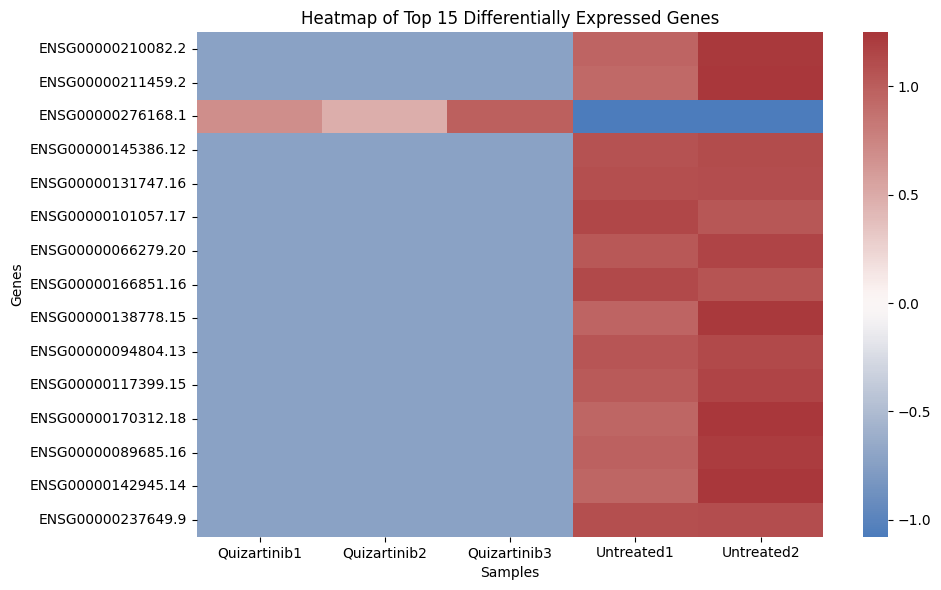

In [69]:
plt.figure(figsize=(10,6))

sns.heatmap(
    heatmap_scaled.T,
    cmap="vlag",
    center=0,
    xticklabels=True,
    yticklabels=True
)

plt.title("Heatmap of Top 15 Differentially Expressed Genes")
plt.xlabel("Samples")
plt.ylabel("Genes")

plt.tight_layout()
plt.savefig("heatmap_top15_genes.png", dpi=300)
plt.show()